In [1]:
import os, time, asyncio, litellm
from pathlib import Path
from dotenv import load_dotenv

training_dir = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()), Path("../../").resolve())
load_dotenv(training_dir / ".env")
litellm.drop_params = False

# --- providers to probe ---
# Each entry: slug -> {api_base (or None), api_key_env, reasoning (or None)}
MODELS = {
    "Fireworks GLM-5.2": {
        "slug": "fireworks_ai/accounts/fireworks/models/glm-5p2",
        "api_base": None,
        "api_key_env": "FIREWORKS_API_KEY",
        "reasoning": {"reasoning_effort": "max"},
    },
    "Fireworks GLM-5.2 Fast": {
        "slug": "fireworks_ai/accounts/fireworks/routers/glm-5p2-fast",
        "api_base": None,
        "api_key_env": "FIREWORKS_API_KEY",
        "reasoning": {"reasoning_effort": "max"},
    },
    "Baseten GLM-5.2": {
        "slug": "openai/zai-org/GLM-5.2",
        "api_base": "https://inference.baseten.co/v1",
        "api_key_env": "BASETEN_API_KEY",
        "reasoning": {"reasoning_effort": "max"},
    },
    "Together GLM-5.2": {
        "slug": "together_ai/zai-org/GLM-5.2",
        "api_base": None,
        "api_key_env": "TOGETHER_API_KEY",
        "reasoning": {"reasoning_effort": "max"},
    },
}

TARGETS = [64_000, 128_000, 256_000, 512_000]   # 128k, 256k, 512k
MAX_TOKENS = 150
TIMEOUT_S = 600

FILLER_URL = "https://raw.githubusercontent.com/eval-protocol/python-sdk/main/development/gsm8k_sample.jsonl"
import urllib.request, json as _json
_raw = urllib.request.urlopen(FILLER_URL).read().decode().splitlines()
FILLER = []
for line in _raw:
    if not line.strip(): continue
    row = _json.loads(line)
    for m in row["messages"]:
        if m["role"] in ("system", "user") and m["content"]:
            FILLER.append(m["content"])
    if len(FILLER) >= 1000: break
print(f"Loaded {len(FILLER)} filler strings")

Loaded 1000 filler strings


In [2]:
def build_prompt(model: str, target_tokens: int) -> list[dict]:
    body = "\n\n".join(FILLER)
    while litellm.token_counter(model=model, text=body) < target_tokens:
        body += "\n\n" + "\n\n".join(FILLER)
    per_char = litellm.token_counter(model=model, text=body) / max(1, len(body))
    body = body[: int(target_tokens / per_char) + 100]
    return [{"role": "user", "content": body + "\n\nWhat is 2+2? Answer with just the number."}]

def _looks_like_context_error(msg: str) -> bool:
    m = msg.lower()
    return any(s in m for s in (
        "context length", "maximum context", "max context", "input length",
        "maximum allowed input", "too many tokens", "exceeds the maximum",
        "context window", "maximum input", "prompt is too long",
    ))

async def probe(name: str, cfg: dict, target: int) -> dict:
    """Streaming probe capturing TTFT + AA-style decode tok/s.

    Streaming so we can split latency into prefill (TTFT) and decode
    (latency - TTFT). Decode tok/s = out_tokens / (latency - ttft) excludes
    prefill -- the Artificial Analysis 'Output Speed' definition
    (https://artificialanalysis.ai/methodology/performance-benchmarking).
    """
    slug = cfg["slug"]
    msgs = build_prompt(slug, target)
    est = litellm.token_counter(model=slug, messages=msgs)
    kw = {}
    if cfg.get("api_base"): kw["api_base"] = cfg["api_base"]
    key = os.getenv(cfg["api_key_env"]) if cfg.get("api_key_env") else None
    if key: kw["api_key"] = key
    if cfg.get("reasoning"): kw["extra_body"] = dict(cfg["reasoning"])
    # stream_options so the provider sends a final usage chunk (without this,
    # streaming responses have usage=None on most providers, so actual/out are -).
    kw["stream_options"] = {"include_usage": True}
    t0 = time.perf_counter()
    ttft = None
    chunks = []
    reasoning_chunks = []   # GLM-5.2 streams reasoning via delta.reasoning_content
    last_ev = None
    try:
        stream = await litellm.acompletion(
            model=slug, messages=msgs, max_tokens=MAX_TOKENS,
            timeout=TIMEOUT_S, stream=True, **kw,
        )
        async for ev in stream:
            last_ev = ev
            delta = ev.choices[0].delta if getattr(ev, "choices", None) else None
            piece = getattr(delta, "content", None) if delta else None
            r_piece = getattr(delta, "reasoning_content", None) if delta else None
            # TTFT = first token of any kind (answer OR reasoning). With
            # reasoning_effort=max the model often reasons all the way to
            # max_tokens without emitting delta.content, so counting only
            # content made TTFT show as "-" on those rows.
            if piece or r_piece:
                if ttft is None:
                    ttft = time.perf_counter() - t0
                if piece: chunks.append(piece)
                if r_piece: reasoning_chunks.append(r_piece)
        dt = time.perf_counter() - t0
        text = "".join(chunks)
        reasoning_text = "".join(reasoning_chunks)
        usage = getattr(last_ev, "usage", None) or getattr(stream, "usage", None)
        u = usage
        actual = getattr(u, "prompt_tokens", None) if u else None
        out_tok = getattr(u, "completion_tokens", None) if u else None
        # Fall back to local token count if the provider didn't return usage
        # (some OpenAI-compatible endpoints ignore include_usage). Count both
        # answer + reasoning tokens since both are generated output.
        if out_tok is None:
            _cnt = 0
            if text: _cnt += litellm.token_counter(model=slug, text=text)
            if reasoning_text: _cnt += litellm.token_counter(model=slug, text=reasoning_text)
            if _cnt: out_tok = _cnt
        decode_tps = (out_tok / (dt - ttft)) if (out_tok and ttft and dt > ttft) else 0.0
        return {"name": name, "target": target, "est": est, "actual": actual,
                "out": out_tok, "ok": True, "past_cap": False, "latency": dt,
                "ttft": ttft if ttft is not None else float("nan"),
                "decode_tok_per_sec": decode_tps,
                "decode_tok_per_sec_eff": (out_tok / dt) if (out_tok and dt) else 0.0}
    except Exception as e:
        msg = repr(e)
        past = _looks_like_context_error(msg)
        return {"name": name, "target": target, "est": est, "actual": None, "out": None,
                "ok": False, "past_cap": past, "latency": time.perf_counter() - t0,
                "ttft": float("nan"), "decode_tok_per_sec": 0.0,
                "decode_tok_per_sec_eff": 0.0, "error": msg[:200]}

print(f"{'provider':>22} {'target':>8} {'actual':>8} {'status':>9} {'lat':>7} {'ttft':>6} {'dec t/s':>7} {'eff t/s':>7}  result")
results = []   # list of per-probe dicts, for the plot cell
for name, cfg in MODELS.items():
    for tgt in TARGETS:
        r = await probe(name, cfg, tgt)
        results.append(r)
        _act = str(r['actual']) if r['actual'] is not None else "-"
        _ttft = f"{r['ttft']:>5.1f}s" if r['ok'] and r['ttft'] == r['ttft'] else "    - "
        _dec  = f"{r['decode_tok_per_sec']:>7.1f}" if r['ok'] else "      -"
        _eff  = f"{r['decode_tok_per_sec_eff']:>7.1f}" if r['ok'] else "      -"
        if r['ok']:
            status, result = "OK", f"out={r['out']}"
        elif r['past_cap']:
            status, result = "PAST CAP", "UNABLE to process -- past max context cap"
        else:
            status, result = "ERR", r.get('error', '')
        print(f"{r['name']:>22} {r['target']:>8} {_act:>8} {status:>9} {r['latency']:>6.1f}s {_ttft} {_dec} {_eff}  {result}")
    print()

              provider   target   actual    status     lat   ttft dec t/s eff t/s  result
     Fireworks GLM-5.2    64000        -        OK    4.8s   2.3s    58.9    30.9  out=148
     Fireworks GLM-5.2   128000        -        OK    7.9s   6.0s    81.0    19.1  out=150
     Fireworks GLM-5.2   256000        -        OK   27.1s  24.2s    51.4     5.5  out=150
     Fireworks GLM-5.2   512000        -        OK   36.2s  33.6s    57.2     4.1  out=150

Fireworks GLM-5.2 Fast    64000        -        OK   18.8s  17.9s   157.5     8.0  out=150
Fireworks GLM-5.2 Fast   128000        -        OK   33.7s  32.7s   154.0     4.4  out=150
Fireworks GLM-5.2 Fast   256000        -        OK   46.8s  45.7s   133.0     3.2  out=150
Fireworks GLM-5.2 Fast   512000        -        OK  109.0s 108.6s   349.5     1.4  out=150

       Baseten GLM-5.2    64000    63634        OK    3.7s   2.0s    84.2    40.0  out=150
       Baseten GLM-5.2   128000   127253        OK    9.0s   7.8s    85.9    11.5  out=10

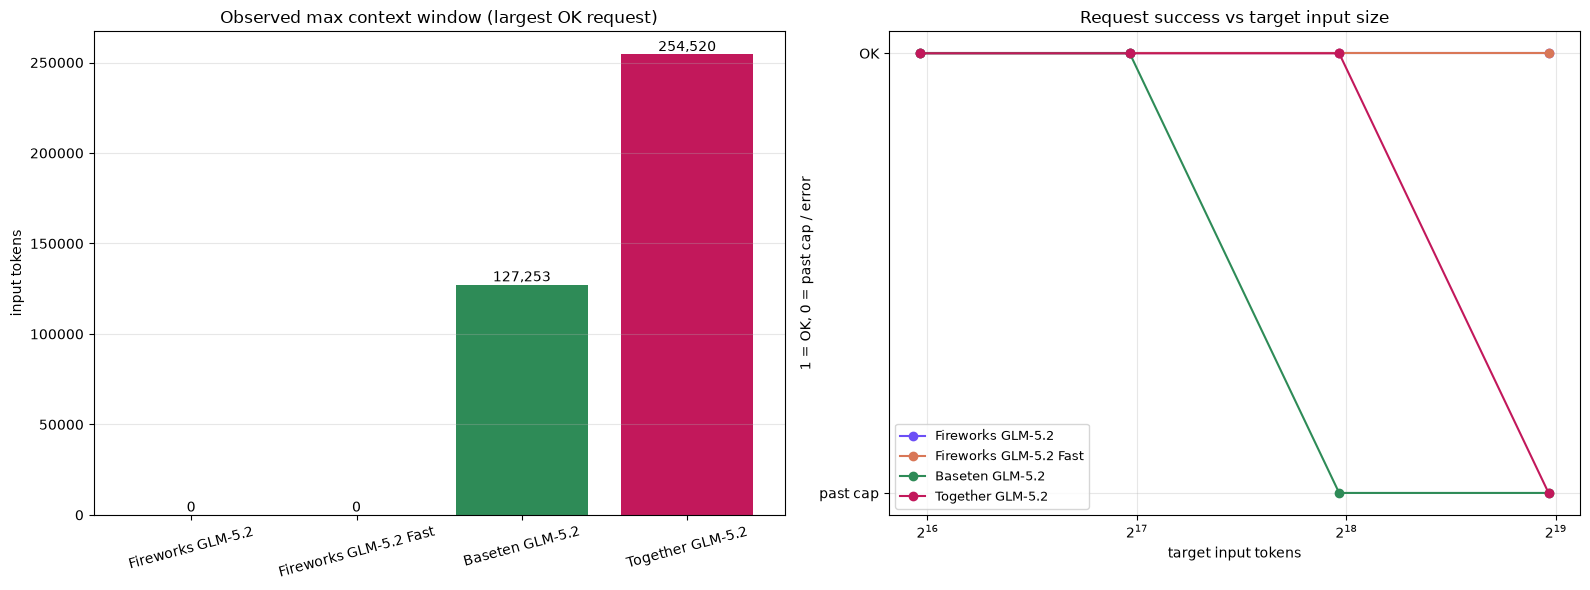

Saved context_window_smoke.png


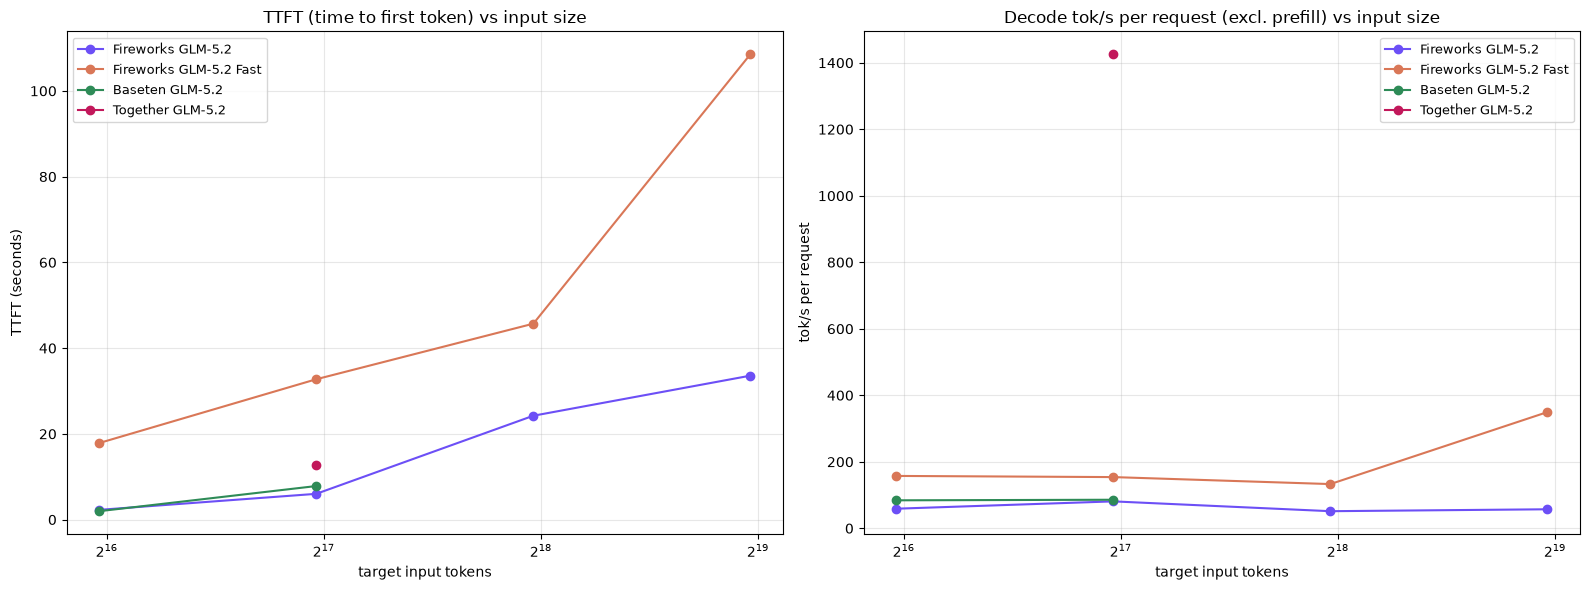

Saved context_window_smoke_latency.png


In [3]:
import matplotlib.pyplot as plt
from itertools import cycle

names = list(MODELS.keys())
_palette = ["#6C4FF6", "#D97757", "#2E8B57", "#C2185B", "#1565C0", "#F9A825"]
colors = {n: c for n, c in zip(names, cycle(_palette))}

# Per provider: the largest target that came back OK = observed max context.
max_ok = {}
for n in names:
    ok_rows = [r for r in results if r['name'] == n and r['ok']]
    max_ok[n] = max((r['actual'] for r in ok_rows if r['actual']), default=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: bar chart of observed max context per provider ---
bars = axes[0].bar(names, [max_ok[n] for n in names], color=[colors[n] for n in names])
axes[0].set_title("Observed max context window (largest OK request)")
axes[0].set_ylabel("input tokens")
axes[0].tick_params(axis="x", rotation=15)
for b, n in zip(bars, names):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height(), f"{max_ok[n]:,}",
                 ha="center", va="bottom", fontsize=10)
axes[0].grid(True, alpha=0.3, axis="y")

# --- Plot 2: success/fail vs target, one line per provider ---
# y = 1 if OK, 0 if past-cap/err. Shows where each provider flips.
for n in names:
    rows = sorted([r for r in results if r['name'] == n], key=lambda r: r['target'])
    xs = [r['target'] for r in rows]
    ys = [1 if r['ok'] else 0 for r in rows]
    axes[1].plot(xs, ys, "o-", label=n, color=colors[n])
axes[1].set_title("Request success vs target input size")
axes[1].set_xlabel("target input tokens")
axes[1].set_ylabel("1 = OK, 0 = past cap / error")
axes[1].set_xscale("log", base=2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["past cap", "OK"])
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("context_window_smoke.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved context_window_smoke.png")

# --- Plot 3 & 4: latency metrics vs target input size ---
# TTFT (prefill) and per-request decode tok/s (AA Output Speed, excl. prefill).
# Only plot OK rows; these metrics are NaN/0 for past-cap or errored probes.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TTFT vs target input size -- prefill time scaling.
for n in names:
    rows = sorted([r for r in results if r['name'] == n and r['ok']
                   and r['ttft'] == r['ttft']], key=lambda r: r['target'])
    if not rows: continue
    xs = [r['target'] for r in rows]
    axes[0].plot(xs, [r['ttft'] for r in rows], "o-", label=n, color=colors[n])
axes[0].set_title("TTFT (time to first token) vs input size")
axes[0].set_xlabel("target input tokens")
axes[0].set_ylabel("TTFT (seconds)")
axes[0].set_xscale("log", base=2)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Decode tok/s per request (excl. prefill) vs input size.
# Peak = fastest request -- here each (provider,target) is a single request,
# so this is just that request's decode t/s. Useful for seeing whether decode
# speed collapses at very long context (KV-cache pressure).
for n in names:
    rows = sorted([r for r in results if r['name'] == n and r['ok']
                   and r['decode_tok_per_sec'] > 0], key=lambda r: r['target'])
    if not rows: continue
    xs = [r['target'] for r in rows]
    axes[1].plot(xs, [r['decode_tok_per_sec'] for r in rows], "o-",
                 label=n, color=colors[n])
axes[1].set_title("Decode tok/s per request (excl. prefill) vs input size")
axes[1].set_xlabel("target input tokens")
axes[1].set_ylabel("tok/s per request")
axes[1].set_xscale("log", base=2)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("context_window_smoke_latency.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved context_window_smoke_latency.png")